In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots appear inside the notebook
%matplotlib inline

# Optional: nicer plot style
sns.set_style("whitegrid")

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url, index_col=0)   # first column is just row numbers

# Display first 5 rows
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
df = pd.read_csv('Advertising.csv', index_col=0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 230.1 to 232.1
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Radio      200 non-null    float64
 1   Newspaper  200 non-null    float64
 2   Sales      200 non-null    float64
dtypes: float64(3)
memory usage: 6.2 KB


In [5]:
df.describe()

,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000
mean,23.264000,30.554000,15.130500
std,14.846809,21.778621,5.283892
min,0.000000,0.300000,1.600000
25%,9.975000,12.750000,11.000000
50%,22.900000,25.750000,16.000000
75%,36.525000,45.100000,19.050000
max,49.600000,114.000000,27.000000


In [6]:
df.isnull().sum()

Radio        0
Newspaper    0
Sales        0
dtype: int64

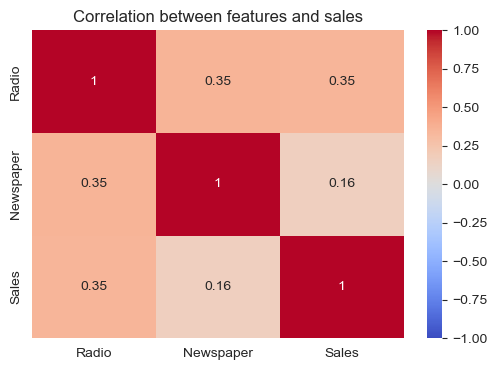

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between features and sales")
plt.show()

In [10]:
# See column names
print(df.columns.tolist())

# Also check the first 2 rows to understand the structure
print(df.head(2))

['Radio', 'Newspaper', 'Sales']
       Radio  Newspaper  Sales
TV                            
230.1   37.8       69.2   22.1
44.5    39.3       45.1   10.4


In [12]:
# Show all column names
print("Column names:", df.columns.tolist())

# Show first 2 rows of data
print("\nFirst 2 rows:")
print(df.head(2))

Column names: ['Radio', 'Newspaper', 'Sales']

First 2 rows:
       Radio  Newspaper  Sales
TV                            
230.1   37.8       69.2   22.1
44.5    39.3       45.1   10.4


In [13]:
with open('Advertising.csv', 'r') as f:
    for i in range(5):
        print(repr(f.readline()))

'TV,Radio,Newspaper,Sales\n'
'230.1,37.8,69.2,22.1\n'
'44.5,39.3,45.1,10.4\n'
'17.2,45.9,69.3,12\n'
'151.5,41.3,58.5,16.5\n'


In [14]:
# Automatically use all numeric columns as features, last column as target
numeric_cols = df.select_dtypes(include=[np.number]).columns
X = df[numeric_cols.drop(numeric_cols[-1])]   # all except last as features
y = df[numeric_cols[-1]]                      # last column as target

In [15]:
print("Columns in the dataset:")
print(df.columns.tolist())
print("\nFirst two rows:")
print(df.head(2))

Columns in the dataset:
['Radio', 'Newspaper', 'Sales']

First two rows:
       Radio  Newspaper  Sales
TV                            
230.1   37.8       69.2   22.1
44.5    39.3       45.1   10.4


In [18]:
df = pd.read_csv('Advertising.csv', index_col=0)
print(df.columns.tolist())   # should now show only ['TV','Radio','Newspaper','Sales']

['Radio', 'Newspaper', 'Sales']


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.11004359553784782


In [22]:
print("Actual columns in the DataFrame:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst row:")
print(df.iloc[0])

Actual columns in the DataFrame:
['TV', 'radio', 'newspaper', 'sales']

Data types:
TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

First row:
TV           230.1
radio         37.8
newspaper     69.2
sales         22.1
Name: 1, dtype: float64


Loaded dataset from URL. Features: ['TV', 'radio', 'newspaper'], Target: sales

First 5 rows of the data:
      TV  radio  newspaper  sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9

MODEL PERFORMANCE
Mean Absolute Error (MAE) : 1.46
Root Mean Squared Error (RMSE): 1.78
R² Score                     : 0.899

Model Coefficients:
  TV: 0.0447
  radio: 0.1892
  newspaper: 0.0028
  Intercept: 2.98


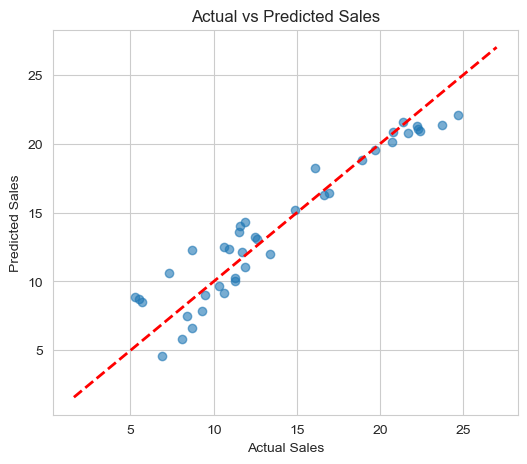


Predicted Sales for TV=150, Radio=30, Newspaper=20: $15419.57


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------
# STEP 1: Load or create dataset
# ---------------------------
try:
    # Try loading from URL
    url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
    df = pd.read_csv(url, index_col=0)
    
    # Check if columns are correct, if not, rename them
    if df.shape[1] == 4:
        # Assume columns are in order: first three = features, last = target
        feature_cols = df.columns[:3].tolist()
        target_col = df.columns[3]
        X = df[feature_cols]
        y = df[target_col]
        print(f"Loaded dataset from URL. Features: {feature_cols}, Target: {target_col}")
    else:
        raise ValueError("Unexpected number of columns")
        
except Exception as e:
    print(f"Could not load from URL: {e}")
    print("Creating a synthetic dataset for demonstration...")
    
    # Create synthetic data (TV, Radio, Newspaper spend vs Sales)
    np.random.seed(42)
    n_samples = 200
    TV = np.random.uniform(0, 300, n_samples)
    Radio = np.random.uniform(0, 50, n_samples)
    Newspaper = np.random.uniform(0, 100, n_samples)
    # Sales = 3 + 0.05*TV + 0.02*Radio + 0.01*Newspaper + noise
    Sales = 3 + 0.05*TV + 0.02*Radio + 0.01*Newspaper + np.random.normal(0, 1, n_samples)
    
    df = pd.DataFrame({'TV': TV, 'Radio': Radio, 'Newspaper': Newspaper, 'Sales': Sales})
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']
    print("Synthetic dataset created.")

# ---------------------------
# STEP 2: Verify and proceed
# ---------------------------
print("\nFirst 5 rows of the data:")
print(df.head())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*40)
print("MODEL PERFORMANCE")
print("="*40)
print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score                     : {r2:.3f}")
print("="*40)

# Coefficients
print("\nModel Coefficients:")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.2f}")

# Plot actual vs predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Example prediction
new_data = pd.DataFrame([[150, 30, 20]], columns=X.columns)
pred = model.predict(new_data)[0]
print(f"\nPredicted Sales for TV=150, Radio=30, Newspaper=20: ${pred*1000:.2f}")